In [ ]:
import optuna
import deepchem as dc

# 1. Cargamos el estudio desde el archivo .db
storage_name = "sqlite:///../studies/lrrk2_study_GAT.db"
study = optuna.load_study(study_name="lrrk2_optimization", storage=storage_name)

# 2. Defines la arquitectura (DEBE ser igual a la de Optuna)
modelGAT = dc.models.GATModel(
    n_tasks=1,
    graph_attention_layers=[16] * study.best_params['n_layers'],
    n_attention_heads=study.best_params['n_heads'],
    # ... resto de parámetros ...
    model_dir="../models/GATModelLRRK2/" 
)

# 3. Restauras los pesos
modelGAT.restore()

In [ ]:
import optuna
import deepchem as dc

protein = "CHEMBL217"

data_path = f"../data/{protein}_nonredundant.csv"

featurizer = dc.feat.CircularFingerprint(size=2048, radius=2)
loader = dc.data.CSVLoader(
    tasks=["pchembl_value"],
    feature_field="canonical_smiles",
    featurizer=featurizer
)
dataset = loader.create_dataset(data_path)

splitter = dc.splits.ScaffoldSplitter()
train_ds, valid_ds, test_ds = splitter.train_valid_test_split(
    dataset, frac_train=0.8, frac_valid=0.1, frac_test=0.1, seed=42    
)

In [3]:
import numpy as np

# 1. Definimos la métrica (Pearson R2 es estándar en química)
metric = dc.metrics.Metric(dc.metrics.pearson_r2_score)
metric_rmse = dc.metrics.Metric(dc.metrics.rms_score)

# 2. Evaluamos el modelo
train_score_GAT = modelGAT.evaluate(train_dataset_GAT, [metric])
valid_score_GAT = modelGAT.evaluate(valid_dataset_GAT, [metric])
test_score_GAT = modelGAT.evaluate(test_dataset_GAT, [metric, metric_rmse])
test_rmse = modelGAT.evaluate(test_dataset_GAT, [metric_rmse])

print(f"R^2 en Entrenamiento: {train_score_GAT['pearson_r2_score']:.3f}")
print(f"R^2 en Validación: {valid_score_GAT['pearson_r2_score']:.3f}")
print(f"R^2 en Test (Moléculas nuevas): {test_score_GAT['pearson_r2_score']:.3f}")

R^2 en Entrenamiento: 0.866
R^2 en Validación: 0.513
R^2 en Test (Moléculas nuevas): 0.556


In [4]:
featurizer = dc.feat.CircularFingerprint(size=2048, radius=2)

def transform_to_morgan(dc_dataset):
    # Extraemos los SMILES que están guardados en el atributo .ids
    smiles_list = dc_dataset.ids
    
    # Generamos los Morgan Fingerprints para esos SMILES exactos
    X_morgan = featurizer.featurize(smiles_list)
    
    # Extraemos las etiquetas y (pChEMBL) que ya estaban en el dataset
    y = dc_dataset.y.ravel()
    
    return X_morgan, y

In [4]:
import joblib
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

modelXG = joblib.load("../models/CHEMBL217_xgb.pkl")

X_train, y_train = train_ds.X, train_ds.y
X_valid, y_valid = valid_ds.X, valid_ds.y
X_test, y_test = test_ds.X, test_ds.y

train_pred = modelXG.predict(X_train)
train_score_XG = r2_score(y_train, train_pred)
    
# 2. Métricas en el set de validación (el promedio que dio Optuna)
valid_pred = modelXG.predict(X_valid)
valid_score_XG = r2_score(y_valid, valid_pred)

# 3. Métricas en el set de TEST (el mundo real)
test_pred_XG = modelXG.predict(X_test)
test_score_XG = r2_score(y_test, test_pred_XG)
test_rmse_XG = np.sqrt(mean_squared_error(y_test, test_pred_XG))

print(f"R^2 en Entrenamiento: {train_score_XG:.3f}")
print(f"R^2 en Validación: {valid_score_XG:.3f}")
print(f"R^2 en Test (Moléculas nuevas): {test_score_XG:.3f}")
print(f"RMSE en Test (Moléculas nuevas): {test_rmse_XG:.3f}")

R^2 en Entrenamiento: 0.928
R^2 en Validación: 0.582
R^2 en Test (Moléculas nuevas): 0.530
RMSE en Test (Moléculas nuevas): 0.700


In [6]:
# Predecimos
test_pred_GAT = modelGAT.predict(test_dataset_GAT)
test_true = test_dataset_GAT.y

preds_gat_flat = test_pred_GAT.ravel()
preds_xgb_flat = test_pred_XG.ravel()

mean_pred = (preds_gat_flat + preds_xgb_flat) / 2

test_score_ENS = r2_score(y_test, mean_pred)
test_rmse_ENS = np.sqrt(mean_squared_error(y_test, mean_pred))

print(f"R^2 en Test (Moléculas nuevas): {test_score_ENS:.3f}")
print(f"RMSE en Test (Moléculas nuevas): {test_rmse_ENS:.3f}")

R^2 en Test (Moléculas nuevas): 0.624
RMSE en Test (Moléculas nuevas): 0.742


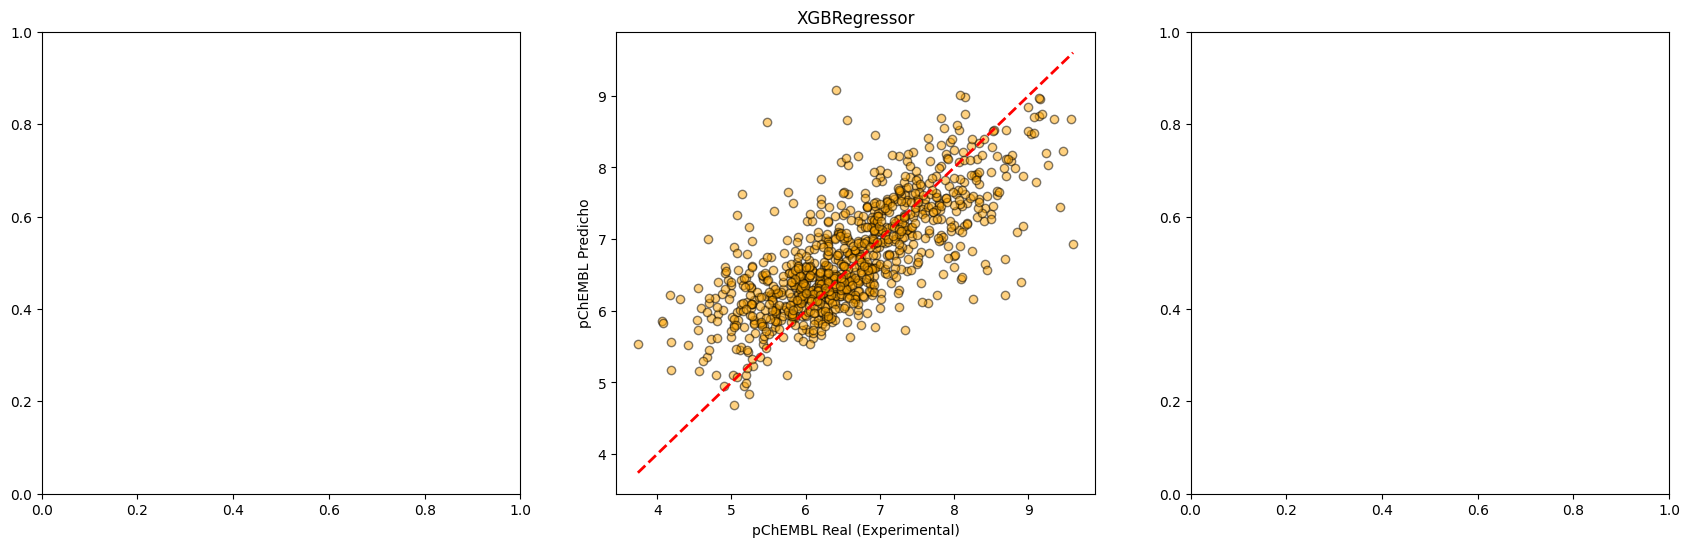

In [7]:
import matplotlib.pyplot as plt

test_true = test_ds.y

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(21, 6))

#ax1.scatter(test_true, test_pred_GAT, alpha=0.5, c='teal', edgecolors='k')
#ax1.plot([test_true.min(), test_true.max()], [test_true.min(), test_true.max()], 'r--', lw=2)
#ax1.set_xlabel('pChEMBL Real (Experimental)')
#ax1.set_ylabel('pChEMBL Predicho')
#ax1.set_title('Graph Attention Network')

ax2.scatter(test_true, test_pred_XG, alpha=0.5, c='orange', edgecolors='k')
ax2.plot([test_true.min(), test_true.max()], [test_true.min(), test_true.max()], 'r--', lw=2)
ax2.set_xlabel('pChEMBL Real (Experimental)')
ax2.set_ylabel('pChEMBL Predicho')
ax2.set_title('XGBRegressor')

#ax3.scatter(test_true, mean_pred, alpha=0.5, c='green', edgecolors='k')
#ax3.plot([test_true.min(), test_true.max()], [test_true.min(), test_true.max()], 'r--', lw=2)
#ax3.set_xlabel('pChEMBL Real (Experimental)')
#ax3.set_ylabel('pChEMBL Predicho')
#ax3.set_title('Mean Value')

plt.show()

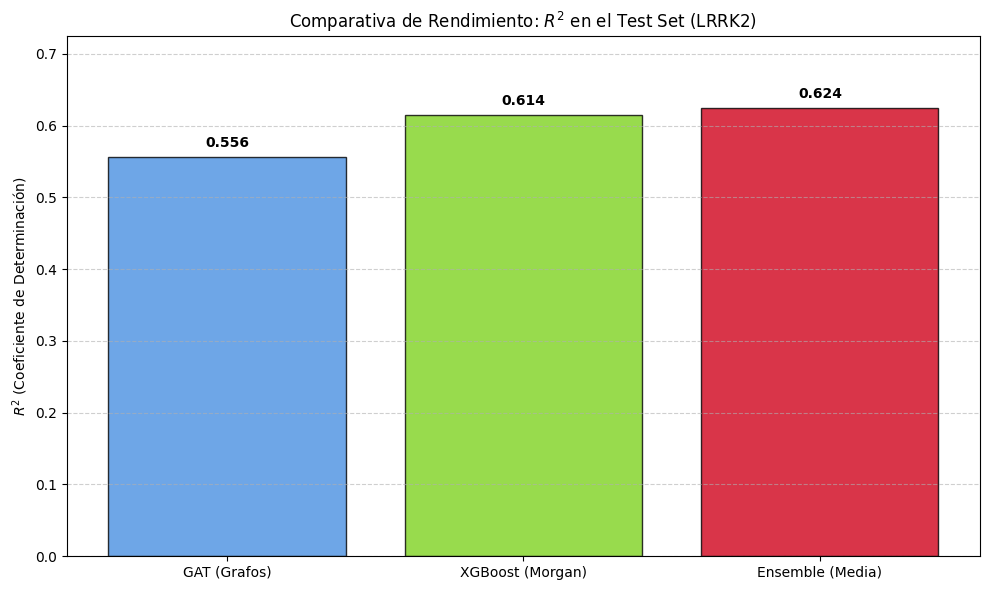

In [8]:
import matplotlib.pyplot as plt

# 1. Definimos los nombres de los modelos y sus resultados de R²
modelos = ['GAT (Grafos)', 'XGBoost (Morgan)', 'Ensemble (Media)']
resultados_r2 = [test_score_GAT['pearson_r2_score'], test_score_XG, test_score_ENS]  # Reemplaza con tus valores reales

# 2. Configuración estética
colores = ['#4A90E2', '#7ED321', '#D0021B'] # Azul, Verde, Rojo

plt.figure(figsize=(10, 6))
bars = plt.bar(modelos, resultados_r2, color=colores, edgecolor='black', alpha=0.8)

# 3. Añadir los valores numéricos encima de cada barra
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, 
             f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

# 4. Detalles del eje y etiquetas
plt.ylim(0, max(resultados_r2) + 0.1) # Damos espacio arriba para el texto
plt.ylabel('$R^2$ (Coeficiente de Determinación)')
plt.title('Comparativa de Rendimiento: $R^2$ en el Test Set (LRRK2)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Mostrar el gráfico
plt.tight_layout()
plt.show()